## Recurrent Neural Network, Classifing and Limitations detection ML algorithmas



---
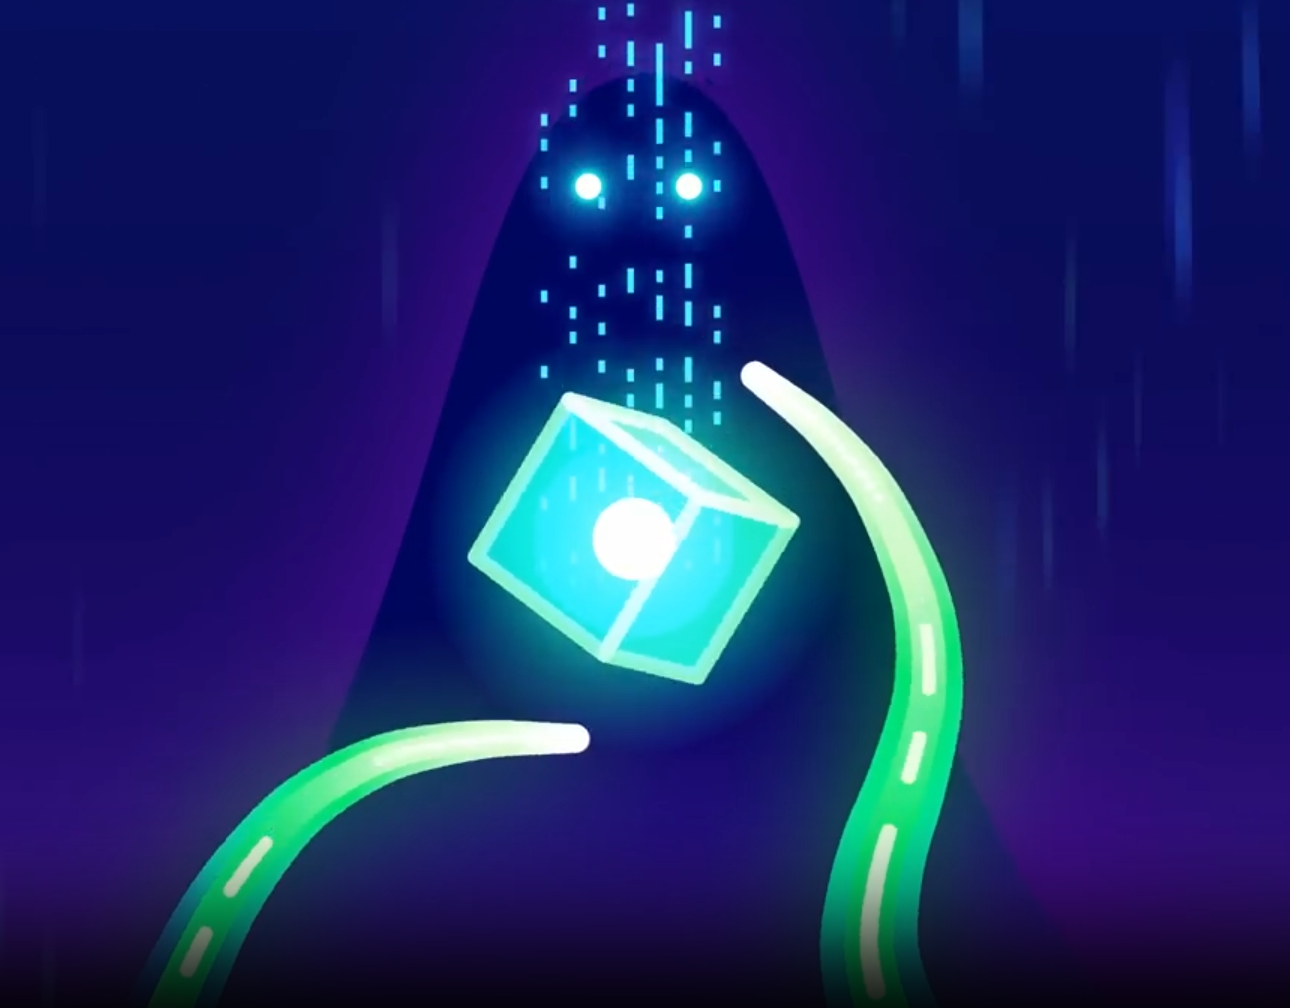





In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 2.0 MB/s eta 0:00:00


Encoding types: **OneHotEncoder, LabelEncoder, Hash**


---


**LabelEncoder**: --> for ordinal data.


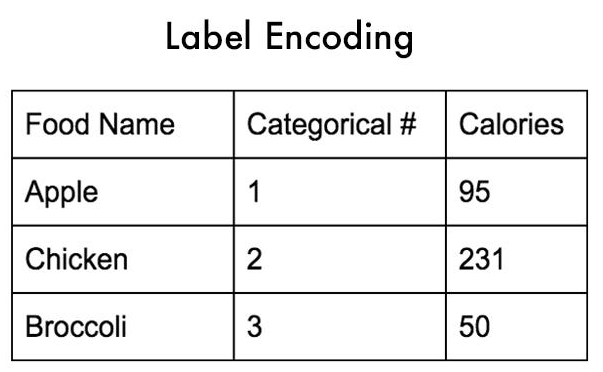

**OneHotEncoder**: --> for nominal data, small number of categories.
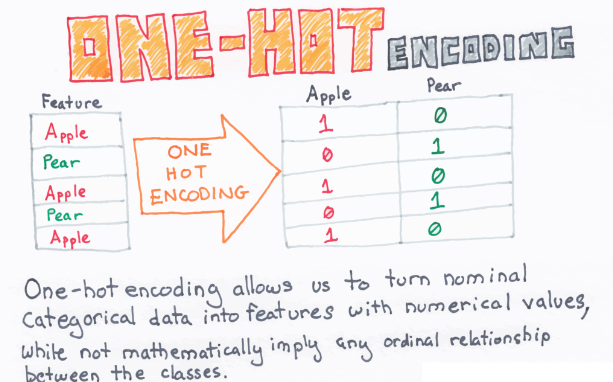

**Hashing**:  --> best for large datasets with high-cardinality features.

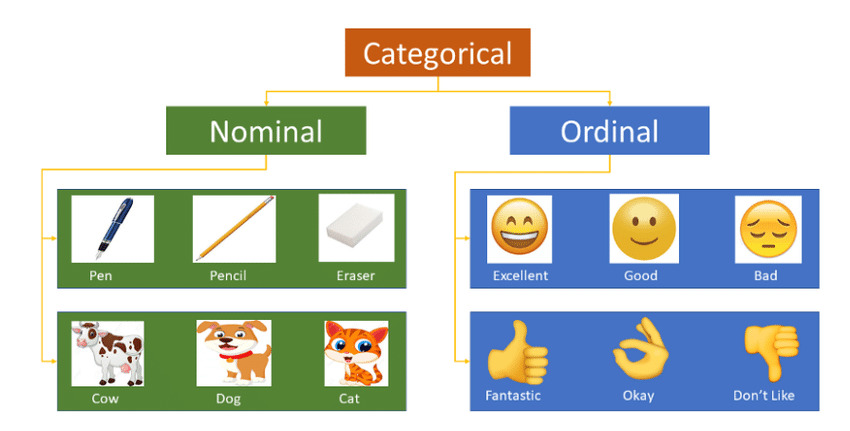

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import hashlib
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

***SMOTE*** resampling

![2024-08-21 16_24_58-Process of Synthetic Minority Oversampling Technique (SMOTE) Algorithm [27] _ Do.png](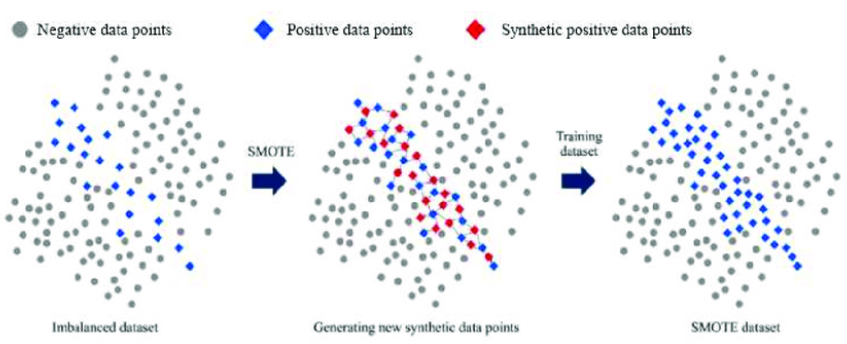)

In [ ]:
tf.keras.backend.clear_session()

For freeing up resources and reseting the Keras state, preventing potential memory leaks when creating new models.

How-Does-Python-Memory-Management-Work_Watermarked.716f0a905800.avif

In [ ]:
def preprocess_inputs(df):
    df = df.copy()
    X = df.drop('Limitation', axis=1)
    y = df['Limitation']
    # Train-test deljenje
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=1)

    # Train-test split for LSTM
    X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=1)

    # Apply SMOTE to the training set for LSTM
    smote = SMOTE(random_state=42)
    X_train_resampled_lstm, y_train_resampled_lstm = smote.fit_resample(X_train_lstm, y_train_lstm)

    # Standardize features for LSTM
    scaler_lstm = StandardScaler()
    X_train_scaled_lstm = scaler_lstm.fit_transform(X_train_resampled_lstm)
    X_test_scaled_lstm = scaler_lstm.transform(X_test_lstm)

    # Reshape data for LSTM input (samples, time steps, features)
    X_train_lstm_reshaped = np.reshape(X_train_scaled_lstm, (X_train_scaled_lstm.shape[0], 1, X_train_scaled_lstm.shape[1]))
    X_test_lstm_reshaped = np.reshape(X_test_scaled_lstm, (X_test_scaled_lstm.shape[0], 1, X_test_scaled_lstm.shape[1]))

    return X_train_lstm_reshaped, X_test_lstm_reshaped, y_train_resampled_lstm, y_test_lstm

Here we apply afro metioned SMOTE.

We need to standardize the features to ensure consistent scaling for better LSTM model performance and reshaped the data to match the LSTM input format, which expects sequences of time steps.


-Measured Time-Dependent data

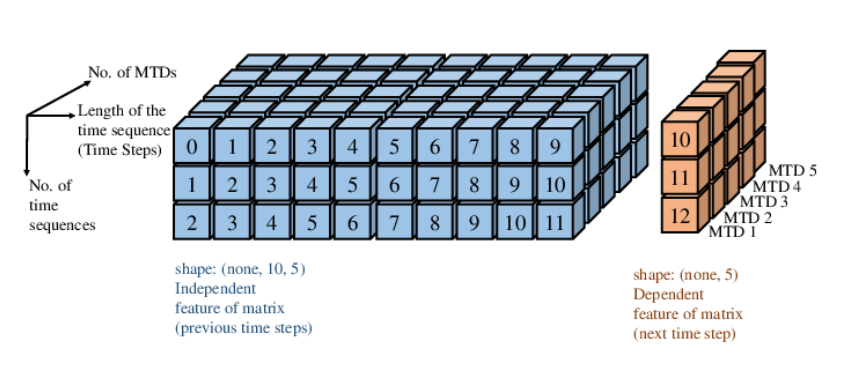

"An example structure of the input data set to LSTM model. Here the light colored time steps are input data while the shaded parts are labels."

In [ ]:
# Importing the data that has previously been cleaned
# Read the first sheet into a DataFrame
df_long = pd.read_excel('merged_longer.xlsx').drop_duplicates().fillna(0)

In [ ]:
# Columns to keep from the original file - shorter verzion
'''columns_to_keep = ['System ID', 'Operator', 'Limitation', 'Network Access TA Start',
                   'Transfer Throughput [kbit/s]', 'Network Access LAT', 'Network Access LON',
                   'LTE PCC SINR Avg','NR PCell SSB Serving Beam SINR Avg', 'Server IP Address',
                   'day_of_week', 'month', 'hour', 'minute', 'second'] #- 62%'''
# Columns to keep from the original file - shorter verzion
'''columns_to_keep = ['System ID', 'Operator', 'Limitation', 'Network Access TA Start',
                   'Transfer Throughput [kbit/s]','LTE PCC SINR Avg','NR PCell SSB Serving Beam SINR Avg',
                   'day_of_week', 'month', 'hour', 'minute', 'second'] #- 46%'''
'''columns_to_keep = ['System ID', 'Operator', 'Limitation', 'Network Access TA Start',
                   'Transfer Throughput [kbit/s]', 'Network Access LAT', 'Network Access LON',
                   'LTE PCC SINR Avg','NR PCell SSB Serving Beam SINR Avg', 'Server IP Address'] #- 60%'''
'''columns_to_keep = ['Limitation', 'Network Access TA Start',
                   'Transfer Throughput [kbit/s]', 'Network Access LAT', 'Network Access LON',
                   'LTE PCC SINR Avg','NR PCell SSB Serving Beam SINR Avg', 'Server IP Address',
                   'day_of_week', 'month', 'hour', 'minute', 'second'] #- 55%'''
'''columns_to_keep = ['System ID', 'Operator', 'Limitation', 'Network Access TA Start',
                   'Transfer Throughput [kbit/s]', 'Network Access LAT', 'Network Access LON',
                   'LTE PCC SINR Avg','NR PCell SSB Serving Beam SINR Avg', 'Server IP Address'] #63%'''
'''columns_to_keep = ['System ID', 'Operator', 'Limitation', 'Network Access TA Start',
                   'Transfer Throughput [kbit/s]', 'LTE PCC SINR Avg','NR PCell SSB Serving Beam SINR Avg', 'Server IP Address'] - 54%'''
'''columns_to_keep = ['Limitation', 'Network Access TA Start',
                   'Transfer Throughput [kbit/s]', 'Network Access LAT', 'Network Access LON',
                   'LTE PCC SINR Avg','NR PCell SSB Serving Beam SINR Avg', 'Server IP Address'] #50%'''
'''columns_to_keep = ['System ID', 'Operator', 'Limitation', 'Network Access TA Start',
                   'Transfer Throughput [kbit/s]', 'Network Access LAT', 'Network Access LON', 'Server IP Address'] #61%'''
'''columns_to_keep = ['Sequence', 'Network Access LAT', 'Network Access LON',
       'Transfer Throughput [kbit/s]', 'Carrier Aggregation PCC Usage [%] DL',
       'Average Used Bandwidth DL', 'E2E spectral efficiency DL',
       'NR Carrier Aggregation SC Usage [%]', 'Transfer Duration [s]',
       'NR PCell PDSCH Average Throughput [Mbit/s]', 'Limitation'] #34%/91%'''
#this one is important done with feature_selection RFE
'''columns_to_keep = ['Sequence', 'Network Access LAT', 'Network Access LON',
       'Transfer Throughput [kbit/s]', 'Carrier Aggregation PCC Usage [%] DL',
       'Average Used Bandwidth DL', 'E2E spectral efficiency DL',
       'NR Carrier Aggregation SC Usage [%]', 'Transfer Duration [s]',
       'NR PCell PDSCH Average Throughput [Mbit/s]', 'Limitation', 'System ID', 'Operator', 'Server IP Address'] #56%/ 96%'''
#when i add network acess TA initaly and then drop it later i have 3% more precision
columns_to_keep = ['System ID', 'Operator', 'Limitation',
                   'Transfer Throughput [kbit/s]', 'Network Access LAT', 'Network Access LON',
                   'LTE PCC SINR Avg','NR PCell SSB Serving Beam SINR Avg', 'Server IP Address'] #62%/88%
'''columns_to_keep = ['Sequence', 'Network Access LAT', 'Network Access LON',
       'Transfer Throughput [kbit/s]', 'Carrier Aggregation PCC Usage [%] DL',
       'Average Used Bandwidth DL', 'E2E spectral efficiency DL',
       'NR Carrier Aggregation SC Usage [%]', 'Transfer Duration [s]',
       'NR PCell PDSCH Average Throughput [Mbit/s]', 'Limitation', 'System ID', 'Operator', 'Server IP Address',
                   'LTE PCC SINR Avg','NR PCell SSB Serving Beam SINR Avg','Network Access TA Start'] # 56%/93% '''
'''columns_to_keep = ['Network Access LAT', 'Network Access LON', 'Network Access TA Start',
       'Transfer Throughput [kbit/s]', 'Carrier Aggregation PCC Usage [%] DL',
       'Average Used Bandwidth DL', 'NR Carrier Aggregation SC Usage [%]', 'Transfer Duration [s]',
       'NR PCell PDSCH Average Throughput [Mbit/s]', 'Limitation', 'System ID', 'Operator', 'Server IP Address']  #58%/91%'''
'''columns_to_keep = ['Network Access LAT', 'Network Access LON', 'Network Access TA Start',
       'Transfer Throughput [kbit/s]', 'Carrier Aggregation PCC Usage [%] DL',
       'Average Used Bandwidth DL', 'NR PCell PDSCH Average Throughput [Mbit/s]',
                   'Limitation', 'System ID', 'Operator', 'Server IP Address'] #60%/93% '''
'''columns_to_keep = ['System ID', 'Operator', 'Limitation', 'Network Access TA Start',
                   'Transfer Throughput [kbit/s]', 'Network Access LAT', 'Network Access LON',
                   'LTE PCC SINR Avg','NR PCell SSB Serving Beam SINR Avg', 'Server IP Address',
                   'Carrier Aggregation PCC Usage [%] DL', 'Average Used Bandwidth DL']  #55%/94% '''
'''columns_to_keep = ['Network Access LAT', 'Network Access LON', 'Network Access TA Start',
       'Transfer Throughput [kbit/s]', 'Carrier Aggregation PCC Usage [%] DL',
       'Average Used Bandwidth DL', 'Limitation', 'Server IP Address']   #49%/93%'''
'''columns_to_keep = ['System ID', 'Operator', 'Limitation', 'Network Access TA Start',
                   'Network Access LAT', 'Network Access LON',
                   'LTE PCC SINR Avg','NR PCell SSB Serving Beam SINR Avg', 'Server IP Address',
                   'Average Used Bandwidth DL', 'NR PCell SSB Serving Beam RSRP Avg',
                   'LTE PCC RSRP Avg']'''

# 'Network Access LAT', 'Network Access LON',
# Keep the specified columns from the DataFrame
df = df_long[columns_to_keep].drop_duplicates()
#df = df.drop(columns=['Network Access TA Start'])


Recursive Feature Elimination (RFE) is a **feature selection technique** that works by recursively removing the **least important features** from a model's feature set. Here’s how it works:

Initialization: RFE starts by training a model (often a classifier or regressor) on the entire set of features.

Feature Ranking: After the initial training, it ranks the features based on their importance derived from the trained model. The importance can be determined by coefficients in linear models or feature importances in tree-based models.


---


**It chose these**, as most important:

*   'Sequence',
*   'Network Access LAT',
*   'Network Access LON',
*   'Transfer Throughput [kbit/s]',
*   'Carrier Aggregation PCC Usage [%] DL',
*   'Average Used Bandwidth DL',
*   'E2E spectral efficiency DL',
*   'NR Carrier Aggregation SC Usage [%]',
*   'Transfer Duration [s]',
*   'NR PCell PDSCH Average Throughput [Mbit/s]'

The next I needed to add as most crutial in our eyes: **'Limitation', 'System ID', 'Operator', 'Server IP Address'**


---





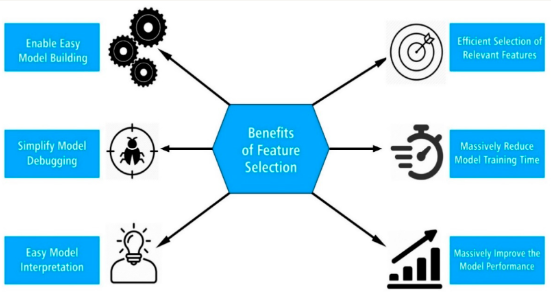

I manualy tried doozens of different combinations, yelding different results. But ultimately the best results were 61-62% with these features:
'System ID', 'Operator', 'Limitation', 'Transfer Throughput [kbit/s]', 'Network Access LAT', 'Network Access LON', 'LTE PCC SINR Avg','NR PCell SSB Serving Beam SINR Avg', 'Server IP Address';

#*To be fair, the reason why this works is not clear to me at all.*

'Network Access LAT', 'Network Access LON' are laregley not important in the manual process of finding limitations. But without them precision is down 10%.

In [ ]:
# Function to hash a string using hashlib
def hash_string(value):
    return int(hashlib.sha256(value.encode()).hexdigest(), 16) % 10**200  # Using 200 digits as example

# Apply the hashing function to each categorical column
def hash_categorical_columns(df, cols):
    for col in cols:
        df[col] = df[col].astype(str).apply(hash_string)
    return df

This proved to yield less accuracy/precision than anticipated - so it wasn't used. But it was supposed to be a more detailed way of hasing string data.

In [ ]:
non_numeric_cols = df.select_dtypes(include=['object']).columns
df[non_numeric_cols] = df[non_numeric_cols].astype(str)
hasher = ce.HashingEncoder(n_components=32, cols=non_numeric_cols, return_df=True)

In [ ]:
df_encoded = hasher.fit_transform(df)
#df_encoded = hash_categorical_columns(df, non_numeric_cols)

In [ ]:
# Print the summary information of the DataFrame
print("\nSummary of the DataFrame:")
print(df_long.info())

# Print the summary information of the DataFrame
print("\nSummary of the DataFrame:")
print(df_encoded.info())

# List all columns
print("Columns in the DataFrame:")
print(df_encoded.columns)

# Display the accessed column
print("\nHead info:")
#print(df.head(20))
print(df_encoded.head(20))


Summary of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45362 entries, 0 to 45361
Columns: 156 entries, System ID to NR SCell7 Power OffsetSS [dB]
dtypes: float64(71), int64(70), object(15)
memory usage: 54.0+ MB
None

Summary of the DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 42257 entries, 0 to 45361
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   col_0                               42257 non-null  int64  
 1   col_1                               42257 non-null  int64  
 2   col_2                               42257 non-null  int64  
 3   col_3                               42257 non-null  int64  
 4   col_4                               42257 non-null  int64  
 5   col_5                               42257 non-null  int64  
 6   col_6                               42257 non-null  int64  
 7   col_7                               4225

In [ ]:
X_train, X_test, y_train, y_test = preprocess_inputs(df_encoded)

In [ ]:
def build_and_train_lstm(X_train_seq, y_train_seq, X_test_seq, y_test_seq, epochs=20, batch_size=32):
    model = Sequential()
    model.add(LSTM(50, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    model.fit(X_train_seq, y_train_seq, epochs=epochs, batch_size=batch_size, validation_split=0.2)

    y_pred = model.predict(X_test_seq).round()
    accuracy = accuracy_score(y_test_seq, y_pred)
    precision = precision_score(y_test_seq, y_pred)
    recall = recall_score(y_test_seq, y_pred)
    f1 = f1_score(y_test_seq, y_pred)
    cm = confusion_matrix(y_test_seq, y_pred)

    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")
    print(classification_report(y_test_seq, y_pred))

    return model


In [ ]:
# Define LSTM model
lstm_model = Sequential() #Creates a linear stack of layers.
#lstm_model.add(LSTM(units=50, input_shape=(1, X_train.shape[2])))

# Add LSTM layer with Dropout
lstm_model.add(LSTM(units=100, input_shape=(1, X_train.shape[2]), return_sequences=True))
lstm_model.add(Dense(1, activation='sigmoid'))

# Compile LSTM model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**units=50**: This parameter specifies the number of LSTM units (neurons) in this layer. More units allow the model to learn more complex patterns but also increase the risk of overfitting, especially with a limited dataset.

**input_shape=(1, X_train.shape[2])**: This specifies the shape of the input data:
The first value 1 indicates that there is only one time step in each input sequence.
X_train.shape[2] refers to the number of features in your input data.

**Adding the Output Layer**
*Dense*: This layer is a fully connected neural network layer. Here, it is used as the output layer.
**1:** This specifies that there is one output unit. In a binary classification problem, the model outputs a single value between 0 and 1.

**activation='sigmoid'**: The sigmoid activation function squashes the output between 0 and 1, making it suitable for binary classification. The model will predict the probability that the input belongs to class 1.

**Compiling the LSTM Model** This function configures the model for training.

**optimizer='adam':** The Adam optimizer is used for adjusting the weights of the network during training.

**loss='binary_crossentropy':** This loss function is used for binary classification tasks.

**metrics=['accuracy']:** This specifies that accuracy will be used as a metric to evaluate the performance of the model during training and testing.

In [ ]:
# Train LSTM model
lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Evaluate LSTM model
lstm_scores = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"LSTM Accuracy: {lstm_scores[1]*100:.2f}%")

Epoch 1/20
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9492 - loss: 0.1782 - val_accuracy: 0.9700 - val_loss: 0.0664
Epoch 2/20
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9830 - loss: 0.0436 - val_accuracy: 0.9733 - val_loss: 0.0527
Epoch 3/20
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9842 - loss: 0.0399 - val_accuracy: 0.9743 - val_loss: 0.0556
Epoch 4/20
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9855 - loss: 0.0377 - val_accuracy: 0.9755 - val_loss: 0.0525
Epoch 5/20
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9859 - loss: 0.0355 - val_accuracy: 0.9753 - val_loss: 0.0508
Epoch 6/20
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9867 - loss: 0.0341 - val_accuracy: 0.9750 - val_loss: 0.0539
Epoch 7/20
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9868 - loss: 0.0340 - val_accuracy: 0.9757 - val_loss: 0.0506
Epoch 8/20
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9880 - loss: 0.0313 

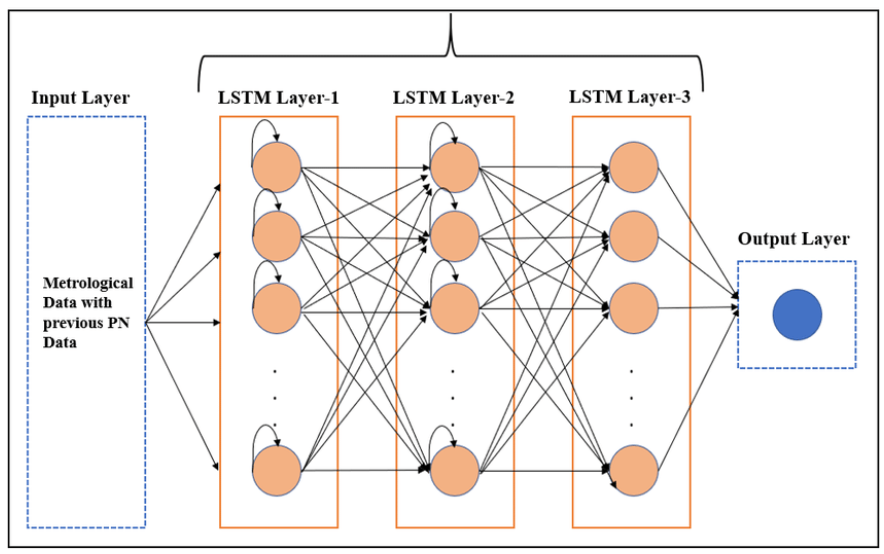

Sequential Long Short-Term Memory (LSTM) architecture.


In [ ]:
# Predict using LSTM model
y_pred_lstm = (lstm_model.predict(X_test) > 0.5).astype(int)
y_pred_lstm = y_pred_lstm.reshape(-1)  # Reshape to (12678,)


# Compute confusion matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print(f"LSTM Confusion Matrix:\n{cm_lstm}")

# Continue with your other models as before for comparison and evaluation
# Calculate evaluation metrics for the LSTM model
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
precision_lstm = precision_score(y_test, y_pred_lstm, average='binary')
recall_lstm = recall_score(y_test, y_pred_lstm, average='binary')
f1_lstm = f1_score(y_test, y_pred_lstm, average='binary')

# Optionally, you can print a classification report
print(classification_report(y_test, y_pred_lstm))

397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM Confusion Matrix:
[[11983   244]
 [   49   402]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     12227
           1       0.62      0.89      0.73       451

    accuracy                           0.98     12678
   macro avg       0.81      0.94      0.86     12678
weighted avg       0.98      0.98      0.98     12678



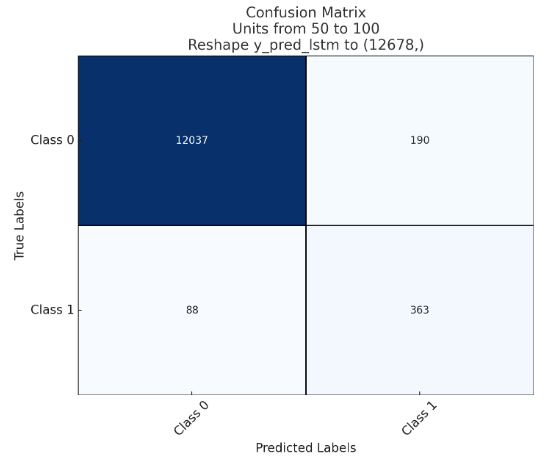


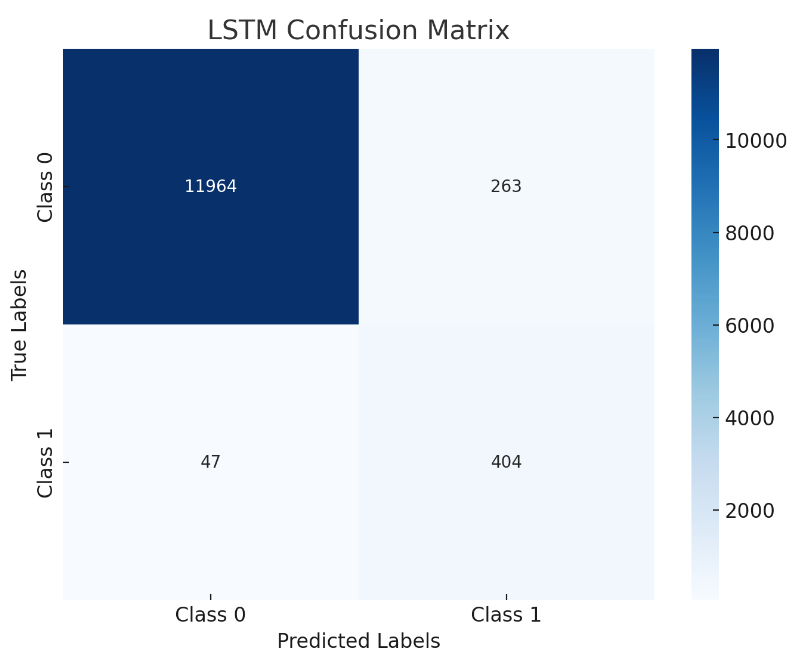

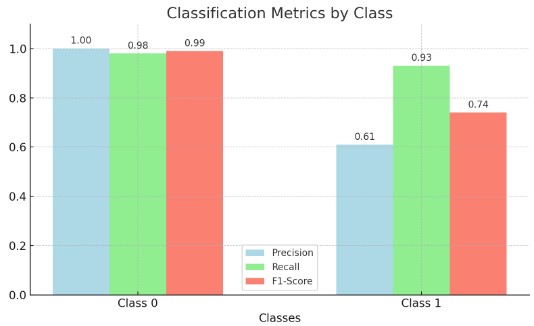


#When changing the units to 100
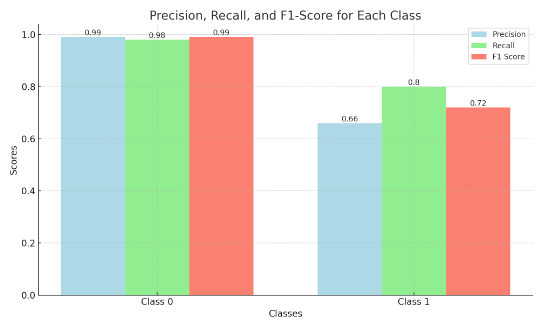

Overall score would be: **0.96578640163**

In [ ]:
'''# Convert predictions to a DataFrame
predictions_df = pd.DataFrame({
    'Predicted_Limitation': y_pred_lstm.flatten()  # Flatten if needed to ensure a 1D array
})

# Reset index if necessary to align with the original DataFrame
predictions_df.reset_index(drop=True, inplace=True)

# Ensure that the original DataFrame (df_long) has been prepared for merging
# If you used df_encoded for model predictions, make sure df_encoded and predictions_df have the same length

# Add predictions to the original DataFrame
df_long_with_predictions = df_long.reset_index(drop=True).join(predictions_df)

# Print or inspect the resulting DataFrame
print(df_long_with_predictions.head())'''

"# Convert predictions to a DataFrame\npredictions_df = pd.DataFrame({\n    'Predicted_Limitation': y_pred_lstm.flatten()  # Flatten if needed to ensure a 1D array\n})\n\n# Reset index if necessary to align with the original DataFrame\npredictions_df.reset_index(drop=True, inplace=True)\n\n# Ensure that the original DataFrame (df_long) has been prepared for merging\n# If you used df_encoded for model predictions, make sure df_encoded and predictions_df have the same length\n\n# Add predictions to the original DataFrame\ndf_long_with_predictions = df_long.reset_index(drop=True).join(predictions_df)\n\n# Print or inspect the resulting DataFrame\nprint(df_long_with_predictions.head())"

# Conclusion


*   Feature Engineering and Selection;
*   Handling Imbalanced Data;
*   Comparison of Encoding Techniques;
*   Choosing ML algorithams;




---


**Personal points:**

*   Working on a smaller data set at first;
*   Being more meticulous in preparing data;
*   More consulting;


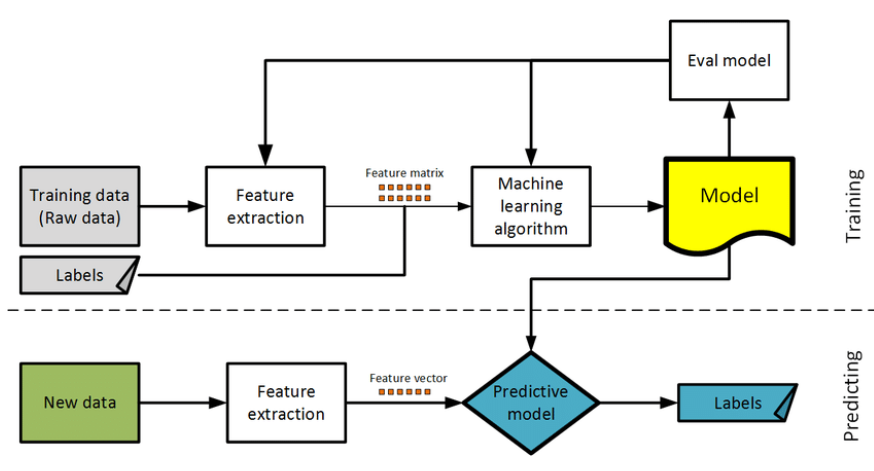

"ML Flowchart"




